In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, TrainingArguments, Trainer

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


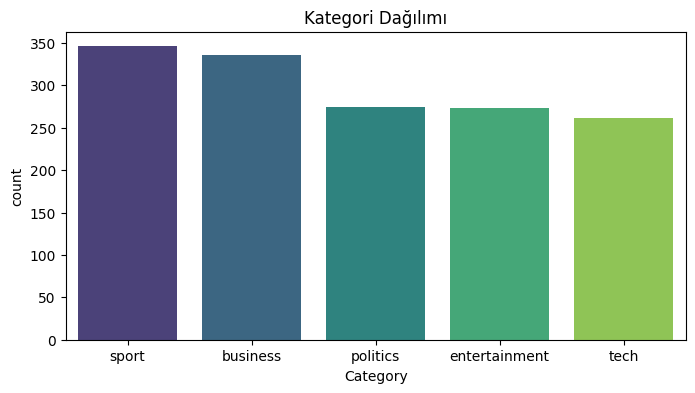

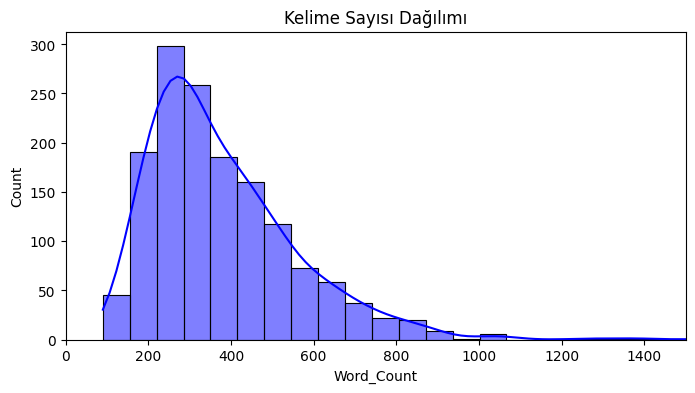

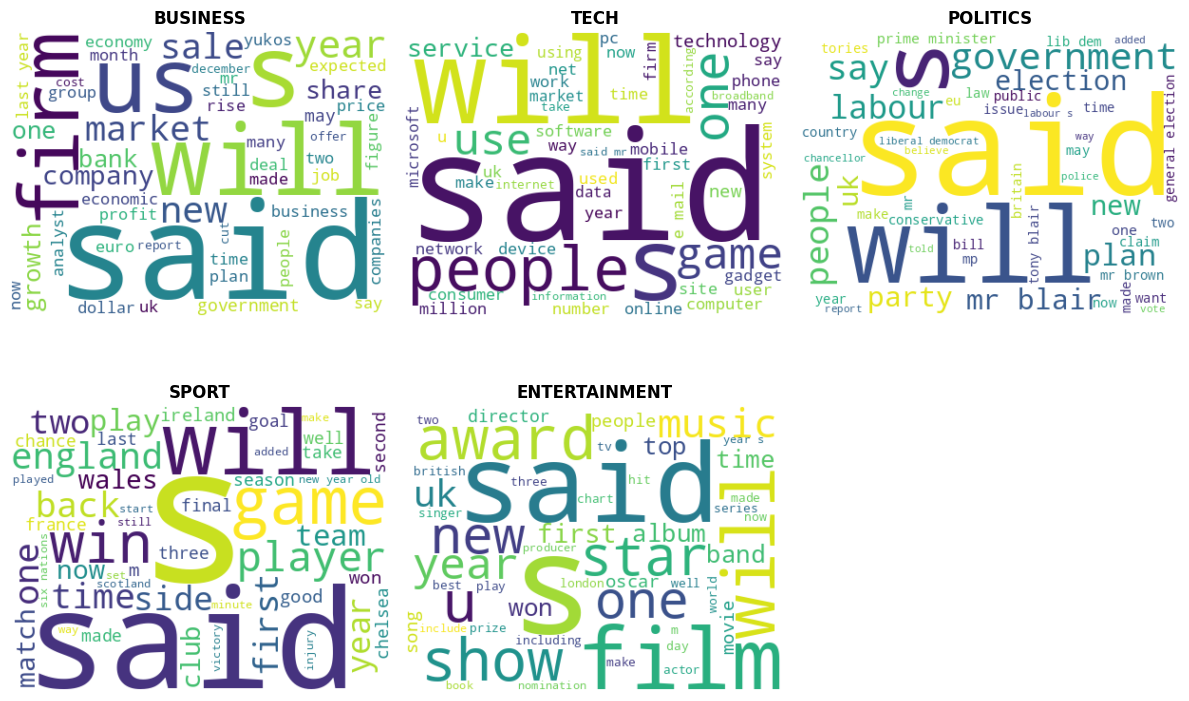

In [13]:
# Veri Setini Yükleme
df = pd.read_csv('BBC News Train.csv')
display(df.head())

# 1. Kategori Dağılımı
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Category', palette='viridis', order=df['Category'].value_counts().index)
plt.title('Kategori Dağılımı')
plt.show()

# 2. Kelime Sayısı Analizi
df['Word_Count'] = df['Text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Word_Count', bins=50, kde=True, color='blue')
plt.title('Kelime Sayısı Dağılımı')
plt.xlim(0, 1500)
plt.show()

# 3. Kelime Bulutları (WordClouds)
categories = df['Category'].unique()
plt.figure(figsize=(12, 8))

for i, category in enumerate(categories, 1):
    text = " ".join(df[df['Category'] == category]['Text'])
    wordcloud = WordCloud(width=400, height=300, background_color='white', max_words=50).generate(text)

    plt.subplot(2, 3, i)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(category.upper(), fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Etiketleri sayısallaştırma
labels_dict = {cat: i for i, cat in enumerate(df['Category'].unique())}
df['label'] = df['Category'].map(labels_dict)

# Eğitim ve doğrulama seti ayrımı (%80 - %20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

# Tokenize işlemleri
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=512)

# PyTorch Dataset yapısı
class BBCDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BBCDataset(train_encodings, train_labels)
val_dataset = BBCDataset(val_encodings, val_labels)

print("Veriler tokenize edildi ve PyTorch formatına çevrildi.")

Veriler tokenize edildi ve PyTorch formatına çevrildi.


In [31]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Eğitim başlatılıyor...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Eğitim başlatılıyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.108791,0.095102,0.979866,0.979771
2,0.019873,0.088575,0.973154,0.972927
3,0.009771,0.060408,0.983221,0.983197


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=225, training_loss=0.19814306053850386, metrics={'train_runtime': 214.1116, 'train_samples_per_second': 16.702, 'train_steps_per_second': 1.051, 'total_flos': 473728761077760.0, 'train_loss': 0.19814306053850386, 'epoch': 3.0})


Sınıflandırma Raporu:
               precision    recall  f1-score   support

     business       0.96      1.00      0.98        75
         tech       1.00      0.95      0.97        58
     politics       1.00      0.96      0.98        56
        sport       1.00      1.00      1.00        63
entertainment       0.96      1.00      0.98        46

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298



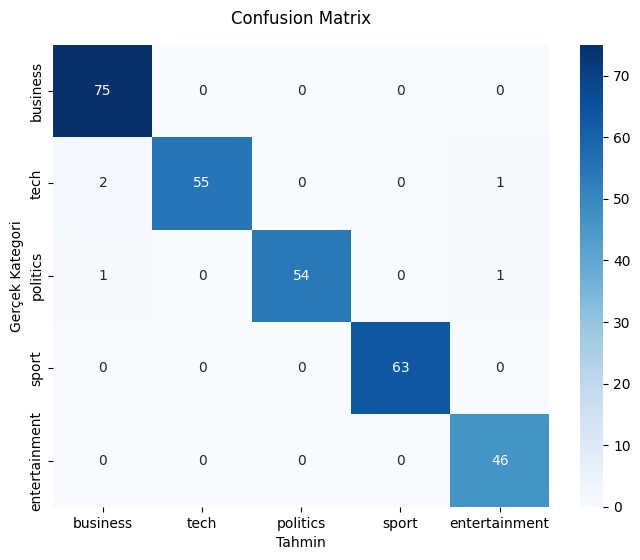

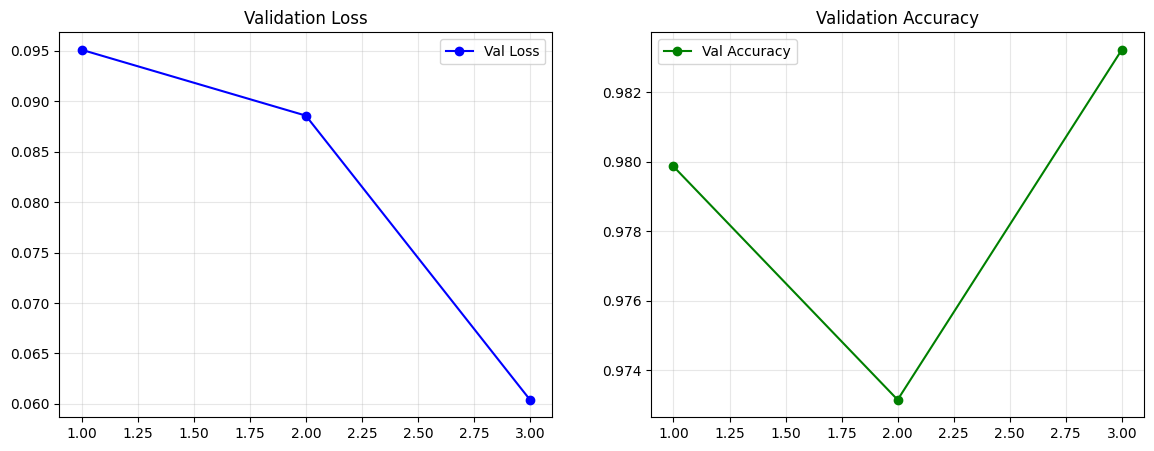

In [32]:
# Tahminleri alma
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids
kategori_isimleri = list(labels_dict.keys())

# Rapor
print("\nSınıflandırma Raporu:")
print(classification_report(y_true, y_pred, target_names=kategori_isimleri))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategori_isimleri,
            yticklabels=kategori_isimleri)
plt.title('Confusion Matrix', pad=15)
plt.xlabel('Tahmin')
plt.ylabel('Gerçek Kategori')
plt.show()

# Eğitim eğrileri (Loss & Accuracy)
log_history = trainer.state.log_history
eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_accuracy = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log]
epochs = range(1, len(eval_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, eval_loss, 'bo-', label='Val Loss')
ax1.set_title('Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, eval_accuracy, 'go-', label='Val Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

In [34]:
import torch

test_metinleri = [
    # 1. Entertainment
    "The highly anticipated sci-fi thriller shattered box office records this weekend, grossing over $150 million globally. Critics are already calling it a cinematic masterpiece, praising the director's visionary visual effects and the lead actor's captivating performance.",

    # 2. Sport
    "Manchester United secured a thrilling 3-2 victory in the final minutes of the Champions League clash. The stadium erupted as the young striker scored the winning goal from outside the penalty box.",

    # 3. Politics
    "The Prime Minister faced intense scrutiny during today's parliamentary session regarding the newly proposed tax reforms. Opposition leaders argued that the policy would disproportionately affect middle-class families.",

    # 4. Tech
    "Apple has announced the release of its new quantum computing chip, promising speeds 100 times faster than current processors. The tech giant's stock surged by 5% following the announcement.",

    # 5. Business
    "Global stock markets rallied today as inflation concerns eased. Major corporate banks reported higher than expected quarterly earnings, driving the S&P 500 to a record high."
]

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

print("CANLI TEST BAŞLIYOR...\n" + "="*80)

id_to_label = {v: k for k, v in labels_dict.items()}

for i, metin in enumerate(test_metinleri, 1):
    inputs = tokenizer(metin, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    olasiliklar = torch.nn.functional.softmax(outputs.logits, dim=-1)
    tahmin_id = torch.argmax(olasiliklar, dim=1).item()
    tahmin_skoru = olasiliklar[0][tahmin_id].item()

    tahmin_edilen_kategori = id_to_label[tahmin_id]

    print(f"Test #{i}")
    print(f"Metin: {metin}")
    print(f"🎯 TAHMİN: {tahmin_edilen_kategori.upper()} (Skor: %{tahmin_skoru * 100:.2f})")
    print("-" * 80)

CANLI TEST BAŞLIYOR...
Test #1
Metin: The highly anticipated sci-fi thriller shattered box office records this weekend, grossing over $150 million globally. Critics are already calling it a cinematic masterpiece, praising the director's visionary visual effects and the lead actor's captivating performance.
🎯 TAHMİN: ENTERTAINMENT (Skor: %98.94)
--------------------------------------------------------------------------------
Test #2
Metin: Manchester United secured a thrilling 3-2 victory in the final minutes of the Champions League clash. The stadium erupted as the young striker scored the winning goal from outside the penalty box.
🎯 TAHMİN: SPORT (Skor: %99.25)
--------------------------------------------------------------------------------
Test #3
Metin: The Prime Minister faced intense scrutiny during today's parliamentary session regarding the newly proposed tax reforms. Opposition leaders argued that the policy would disproportionately affect middle-class families.
🎯 TAHMİN: POLIT